# Week 5 — Zero-Shot Detection with GPT-2: Perplexity, Log-Rank and DetectGPT-lite

**Goal (syllabus unit VI, generative language models):** every detector so far *learned* from our labelled essays. Here we try detecting AI text **without training on any labels**, using only a pretrained generative model, **GPT-2**.

The idea: a language model assigns a probability to every next token. LLM-generated text is produced by picking *high-probability* tokens, so another language model finds it **predictable**. Human writing (especially student writing with typos, odd phrasing and personal detail) is more **surprising**.

Signals, all from one GPT-2 pass per essay:
- **Perplexity:** average surprise. Lower → more AI-like.
- **Burstiness:** how much the surprise *varies* token to token. Humans mix predictable and very surprising words.
- **Log-rank (GLTR):** for each actual token, its rank among GPT-2's predictions (1 = top choice). AI text is full of rank-1/rank-2 tokens.

And one more expensive test:
- **DetectGPT-lite:** slightly rewrite an essay many times and see how much GPT-2's likelihood *drops*. AI text sits near a local *peak* of likelihood, so almost any change lowers it. Human text doesn't sit at a peak, so changes move it up or down.

Then the honest comparison: zero-shot scores vs the supervised models of Weeks 1–4, on the same sets.

In [1]:
import os
import sys
sys.path.append('..')
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import gc
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForMaskedLM
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr

from src.data import load_splits
from src.evaluate import evaluate, evaluate_on_topic, COLUMNS

transformers.logging.set_verbosity_error()
SEED = 42
torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)
pd.set_option('display.width', 200)
HUMAN, AI = '#2a78d6', '#eb6834'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': '#e6e6e3', 'grid.linewidth': 0.6,
                     'axes.edgecolor': '#9a9a94', 'axes.titleweight': 'bold'})
device = torch.device('cuda')

## Step 1 — GPT-2 and what "perplexity" means

**GPT-2 small** (124M parameters, OpenAI 2019) is a *causal* (left-to-right) transformer: at each position it outputs a probability distribution over the next token, having seen only the tokens before it. It was trained on 8M web pages (WebText), i.e. general English, not our essays.

For an essay with tokens $t_1 \dots t_n$, GPT-2 gives each actual token a probability $p(t_i \mid t_{<i})$. Its **negative log-likelihood** $-\log p$ is the *surprise* at that token. Then:
- **mean NLL** = average surprise = the cross-entropy loss GPT-2 would get on this essay;
- **perplexity** = $\exp(\text{mean NLL})$, the "effective number of equally likely choices" per token. Perplexity 20 means GPT-2 was, on average, as unsure as picking among 20 options.

We keep the log scale (**log-perplexity = mean NLL**), which is better behaved than perplexity itself.

**Sanity check first:** GPT-2 should find a normal sentence far less surprising than the same words shuffled, and a misspelled version somewhat more surprising.

In [2]:
gpt_tok = AutoTokenizer.from_pretrained('gpt2')
gpt_tok.pad_token = gpt_tok.eos_token          # GPT-2 has no padding token; reuse end-of-text (masked out anyway)
gpt = AutoModelForCausalLM.from_pretrained('gpt2').to(device).eval()
print(f"GPT-2 small: {sum(p.numel() for p in gpt.parameters()) / 1e6:.0f}M parameters, context {gpt.config.n_positions} tokens")

MAX_LEN = 512

@torch.no_grad()
def token_stats(texts, batch_size=8, max_len=MAX_LEN):
    # Per essay: mean NLL (= log-perplexity), std of NLL (burstiness), mean log-rank of the true token
    out = np.zeros((len(texts), 3), dtype=np.float32)
    enc = gpt_tok(texts, truncation=True, max_length=max_len)['input_ids']
    order = np.argsort([len(x) for x in enc], kind='stable')                      # bucket by length
    for s in range(0, len(order), batch_size):
        chunk = order[s:s + batch_size]
        width = max(len(enc[i]) for i in chunk)
        x = torch.full((len(chunk), width), gpt_tok.eos_token_id, dtype=torch.long)
        mask = torch.zeros_like(x)
        for r, i in enumerate(chunk):
            x[r, :len(enc[i])] = torch.tensor(enc[i]); mask[r, :len(enc[i])] = 1
        x, mask = x.to(device), mask.to(device)
        with torch.autocast('cuda', dtype=torch.float16):
            logits = gpt(input_ids=x, attention_mask=mask).logits[:, :-1].float()   # prediction for token i+1
        target, tmask = x[:, 1:], mask[:, 1:].bool()
        nll = F.cross_entropy(logits.transpose(1, 2), target, reduction='none')        # (batch, len-1)
        true_logit = logits.gather(2, target.unsqueeze(-1))
        rank = (logits > true_logit).sum(-1) + 1                                       # 1 = GPT-2's top choice
        log_rank = torch.log(rank.float())
        for r, i in enumerate(chunk):
            m = tmask[r]
            out[i] = [nll[r][m].mean().item(), nll[r][m].std().item(), log_rank[r][m].mean().item()]
        del logits, nll, true_logit, rank, log_rank
    return out

demo = ["The students argued that the school should allow cell phones during lunch because it helps them stay in touch with their families.",
        "lunch phones school the students their because during argued that should cell allow it helps them in touch with stay families the.",
        "The studnets argud that the scool shuold alow cell phons durring lunch becuase it helpes them stay in tuch with there familys."]
for name, s in zip(['normal', 'shuffled', 'misspelled'], token_stats(demo)):
    print(f"{name:10s}  log-perplexity {s[0]:.2f}  (perplexity {np.exp(s[0]):7.1f})  burstiness {s[1]:.2f}  mean log-rank {s[2]:.2f}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT-2 small: 124M parameters, context 1024 tokens


normal      log-perplexity 3.32  (perplexity    27.6)  burstiness 2.84  mean log-rank 1.62
shuffled    log-perplexity 8.14  (perplexity  3425.6)  burstiness 3.79  mean log-rank 5.29
misspelled  log-perplexity 7.10  (perplexity  1206.0)  burstiness 3.27  mean log-rank 4.69


As expected: shuffled words are wildly surprising, and **misspellings raise perplexity a lot**, a warning sign since student essays are full of them. Step 6 checks how much of the detector is "just" a spelling detector.

## Step 2 — Score every essay

One GPT-2 pass per essay, first 512 tokens (GPT-2's context is 1,024, but 512 keeps the essays comparable with `08`).

In [3]:
data = load_splits()
t0 = time.time()
stats = token_stats(data['text'].tolist())
data['log_ppl'], data['burstiness'], data['log_rank'] = stats[:, 0], stats[:, 1], stats[:, 2]
print(f"scored {len(data):,} essays in {(time.time() - t0) / 60:.1f} min")
data.groupby('label')[['log_ppl', 'burstiness', 'log_rank']].describe().T.round(3).rename(columns={0: 'human', 1: 'AI'})

scored 44,864 essays in 23.6 min


label                 human         AI
log_ppl    count  27371.000  17493.000
           mean       3.371      2.287
           std        0.472      0.527
           min        0.582      0.195
           25%        3.049      1.891
           50%        3.319      2.167
           75%        3.646      2.584
           max        5.945      5.090
burstiness count  27371.000  17493.000
           mean       2.758      2.187
           std        0.268      0.373
           min        1.760      0.929
           25%        2.559      1.915
           50%        2.745      2.088
           75%        2.944      2.414
           max        3.809      6.965
log_rank   count  27371.000  17493.000
           mean       1.737      1.051
           std        0.326      0.343
           min        0.293      0.077
           25%        1.511      0.794
           50%        1.693      0.958
           75%        1.917      1.235
           max        3.683      3.051

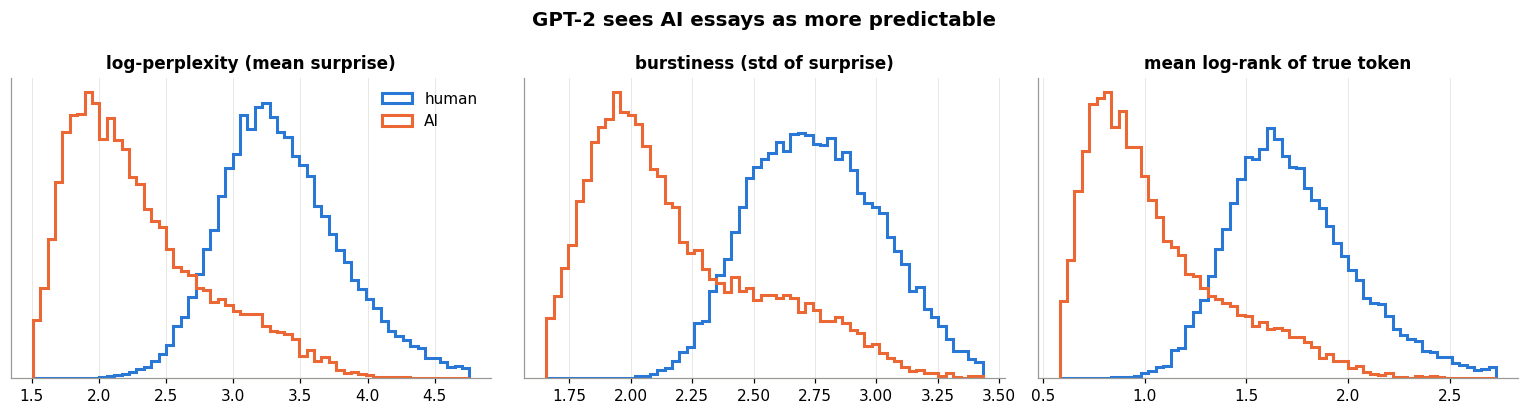

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, col, title in zip(axes, ['log_ppl', 'burstiness', 'log_rank'],
                          ['log-perplexity (mean surprise)', 'burstiness (std of surprise)', 'mean log-rank of true token']):
    lo, hi = data[col].quantile([0.005, 0.995])
    bins = np.linspace(lo, hi, 60)
    for lbl, color, name in [(0, HUMAN, 'human'), (1, AI, 'AI')]:
        ax.hist(data.loc[data['label'] == lbl, col], bins=bins, density=True, histtype='step', linewidth=2, color=color, label=name)
    ax.set_title(title, fontsize=11); ax.set_yticks([])
axes[0].legend(frameon=False)
fig.suptitle('GPT-2 sees AI essays as more predictable', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig('../images/10_gpt2_signals.png', dpi=150, bbox_inches='tight')
plt.show()

All three separate the classes, with **no training on our labels**: AI essays have lower perplexity, less burstiness and lower ranks.

Which generators look most "predictable" to GPT-2? (Mean log-perplexity per source; lower = more predictable.)

In [5]:
by_src = data.groupby(['label', 'source'])['log_ppl'].agg(['size', 'mean']).round(3).sort_values('mean')
by_src['perplexity'] = np.exp(by_src['mean']).round(1)
by_src

size   mean  perplexity
label source                                                      
1     kingki19_palm                        1384  1.706    5.500000
      palm-text-bison1                      349  1.848    6.300000
      mistral7binstruct_v1                 2421  1.867    6.500000
      mistralai/Mistral-7B-Instruct-v0.1    399  1.900    6.700000
      mistral7binstruct_v2                 2419  2.044    7.700000
      falcon_180b_v1                       1055  2.093    8.100000
      llama_70b_v1                         1172  2.174    8.800000
      llama2_chat                          2420  2.213    9.100000
      cohere-command                        350  2.230    9.300000
      NousResearch/Llama-2-7b-chat-hf       400  2.369   10.700000
      radek_500                             500  2.441   11.500000
      chat_gpt_moth                        2421  2.706   15.000000
      train_essays                            3  2.941   18.900000
      radekgpt4                             200  3.159   23.500000
      darragh_claude_v7                    1000  3.259   26.000000
      darragh_claude_v6                    1000  3.273   26.400000
0     persuade_corpus                     25996  3.367   29.000000
      train_essays                         1375  3.445   31.299999

## Step 3 — Zero-shot detectors

A zero-shot score still needs a **threshold** to make decisions. We choose it exactly as in `09_threshold`: on `val` human essays, so that **1% of them are flagged**. That's the only use of labels, and it uses `val` only.

Score direction: lower perplexity / burstiness / log-rank → more AI, so the score is the *negative* value.

In [6]:
val = data[data['split'] == 'val']
test, ho_prompt, ho_gen = (data[data['split'] == s] for s in ['test', 'heldout_prompt', 'heldout_generator'])
sets = (test, ho_prompt, ho_gen)

def threshold_1pct(score_fn):
    return float(np.quantile(score_fn(val[val['label'] == 0]), 0.99))

zero_shot = {
    'GPT-2 perplexity (zero-shot)': lambda d: -d['log_ppl'].to_numpy(),
    'GPT-2 burstiness (zero-shot)': lambda d: -d['burstiness'].to_numpy(),
    'GPT-2 log-rank (zero-shot)':   lambda d: -d['log_rank'].to_numpy(),
}
print("val AUC (no training at all):")
for name, f in zero_shot.items():
    print(f"   {name:30s} {roc_auc_score(val['label'], f(val)):.4f}")

val AUC (no training at all):
   GPT-2 perplexity (zero-shot)   0.9736
   GPT-2 burstiness (zero-shot)   0.9440
   GPT-2 log-rank (zero-shot)     0.9693


**Small supervised combination.** A logistic regression on just these **3 numbers** (trained on `train`) learns how to weigh them. That's a 4-parameter model on top of frozen GPT-2 features, compared with 82M fine-tuned parameters in `08`.

In [7]:
FEATS = ['log_ppl', 'burstiness', 'log_rank']
train = data[data['split'] == 'train']
combo = make_pipeline(StandardScaler(), LogisticRegression()).fit(train[FEATS], train['label'])
print("weights (standardised features):", dict(zip(FEATS, combo[-1].coef_[0].round(2))))
print("val AUC:", round(roc_auc_score(val['label'], combo.predict_proba(val[FEATS])[:, 1]), 4))

detectors = {**zero_shot, 'LogReg on 3 GPT-2 features': lambda d: combo.predict_proba(d[FEATS])[:, 1]}
thresholds = {name: threshold_1pct(f) for name, f in detectors.items()}
all_rows = pd.DataFrame([evaluate(f, thresholds[n], n, *sets) for n, f in detectors.items()])
fair_rows = pd.DataFrame([evaluate_on_topic(f, thresholds[n], n, *sets) for n, f in detectors.items()])

weights (standardised features): {'log_ppl': np.float64(-10.08), 'burstiness': np.float64(-0.22), 'log_rank': np.float64(5.82)}
val AUC: 0.976


Compare with the supervised models (on-topic rows). Supervised rows from `04`/`07`/`08` use their default thresholds, so compare **AUC columns** across the board. F1/detection depend on the threshold; for the GPT-2 rows they're at the val 1%-FPR threshold.

In [8]:
key = ['test_f1', 'test_auc', 'heldout_prompt_f1', 'heldout_prompt_auc', 'heldout_gen_detection', 'heldout_gen_auc']
prev = pd.concat([
    pd.read_csv('../results/06_on_topic.csv', index_col=0).loc[['TF-IDF + LinearSVM (C=1)']],
    pd.read_csv('../results/07_bilstm.csv', index_col=0).query("subset == 'on_topic'").drop(columns='subset').loc[['BiGRU (Skip-gram init)']],
    pd.read_csv('../results/08_bert.csv', index_col=0).query("subset == 'on_topic'").drop(columns='subset').loc[['DistilRoBERTa (fine-tuned)']],
])
pd.concat([prev, fair_rows])[key].round(3)

,test_f1,test_auc,heldout_prompt_f1,heldout_prompt_auc,heldout_gen_detection,heldout_gen_auc
TF-IDF + LinearSVM (C=1),0.994,1.000,0.965,0.997,0.880,1.000
BiGRU (Skip-gram init),0.974,1.000,0.775,0.934,0.955,0.998
DistilRoBERTa (fine-tuned),0.966,1.000,0.941,1.000,0.999,1.000
GPT-2 perplexity (zero-shot),0.842,0.978,0.802,0.939,0.178,0.649
GPT-2 burstiness (zero-shot),0.812,0.948,0.742,0.878,0.160,0.544
GPT-2 log-rank (zero-shot),0.847,0.975,0.818,0.930,0.185,0.617
LogReg on 3 GPT-2 features,0.844,0.980,0.790,0.950,0.169,0.688


## Step 4 — DetectGPT-lite

**DetectGPT** (Mitchell et al., 2023) observes that model-generated text tends to lie at a **local maximum of the model's log-likelihood**: the generator picked likely words, so swapping a few for plausible alternatives almost always makes the text *less* likely. Human text has no such peak, and rewrites move its likelihood up or down.

Procedure for each essay $x$:
1. Make $k = 10$ **perturbations** $\tilde{x}_1 \dots \tilde{x}_k$: mask ~15% of tokens and let a **masked language model** fill them with plausible alternatives. (The paper uses T5; "lite" uses the pretrained, *not* fine-tuned, `distilroberta-base`, which is already downloaded.)
2. Score the original and every perturbation with GPT-2 (mean log-likelihood).
3. **Normalised perturbation discrepancy** $= \frac{\ell(x) - \text{mean}_j\, \ell(\tilde{x}_j)}{\text{std}_j\, \ell(\tilde{x}_j)}$. Large → the original was a peak → AI.

Cost: 11 GPT-2 passes + 10 masked-LM passes per essay, so we run it on a **sample**: on-topic `test` (up to 300 human + 300 AI) plus 200 held-out-generator essays, with each essay cut to its first 256 tokens (the paper used ~200). For a fair comparison, plain perplexity is recomputed on exactly the same truncated texts.

In [9]:
mlm_tok = AutoTokenizer.from_pretrained('distilroberta-base')
mlm = AutoModelForMaskedLM.from_pretrained('distilroberta-base').to(device).eval()
SHORT = 256

@torch.no_grad()
def perturb(texts, frac=0.15, top_k=10, batch_size=16):
    # Mask ~15% of (non-special) tokens and fill each with a sample from the masked LM's top-10
    enc = mlm_tok(texts, truncation=True, max_length=SHORT)['input_ids']
    out = []
    for s in range(0, len(enc), batch_size):
        batch = enc[s:s + batch_size]
        width = max(len(e) for e in batch)
        x = torch.full((len(batch), width), mlm_tok.pad_token_id, dtype=torch.long)
        for r, e in enumerate(batch):
            x[r, :len(e)] = torch.tensor(e)
        special = (x == mlm_tok.pad_token_id) | (x == mlm_tok.bos_token_id) | (x == mlm_tok.eos_token_id)
        pick = (torch.rand(x.shape, generator=torch.Generator().manual_seed(int(rng.integers(1e9)))) < frac) & ~special
        masked = x.clone(); masked[pick] = mlm_tok.mask_token_id
        with torch.autocast('cuda', dtype=torch.float16):
            logits = mlm(input_ids=masked.to(device), attention_mask=(~(x == mlm_tok.pad_token_id)).long().to(device)).logits.float()
        logits[..., mlm_tok.all_special_ids] = -1e9                     # never insert special tokens
        logits.scatter_(2, x.to(device).unsqueeze(-1), -1e9)          # never "replace" a token with itself
        top = logits.topk(top_k, dim=-1)
        choice = torch.multinomial(F.softmax(top.values[pick.to(device)], -1), 1).squeeze(1)
        filled = x.clone().to(device)
        filled[pick.to(device)] = top.indices[pick.to(device)].gather(1, choice.unsqueeze(1)).squeeze(1)
        out += mlm_tok.batch_decode(filled.cpu(), skip_special_tokens=True)
    return out

import difflib
orig_text = mlm_tok.decode(mlm_tok(test['text'].iloc[0], truncation=True, max_length=SHORT)['input_ids'], skip_special_tokens=True)
pert_text = perturb([test['text'].iloc[0]])[0]
a, b = orig_text.split(), pert_text.split()
changed = sum(max(i2 - i1, j2 - j1) for op, i1, i2, j1, j2 in difflib.SequenceMatcher(None, a, b).get_opcodes() if op != 'equal')
print(f"words changed: {changed} of {len(a)} ({changed / len(a) * 100:.0f}%)\n")
print("original :", orig_text[:300])
print("perturbed:", pert_text[:300])

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

words changed: 38 of 218 (17%)

original : Phones

Modern humans today are always on their phone. They are always on their phone more than 5 hours a day no stop .All they do is text back and forward and just have group Chats on social media. They even do it while driving. They are some really bad consequences when stuff happens when it comes
perturbed: Phones

Modern humans today are always on their phone. They are always on their phone more than 5 hours a day no stop . All they do is text back and forward they just have group Chats on social media. They still do texting while driving. There are some really bad consequences when stuff happens when


The perturbed text keeps the meaning and grammar mostly intact but changes ~15% of the words. That's the "nearby alternative" DetectGPT needs.

**A bug caught by the smoke test:** the first version sampled each masked word from the masked LM's top-10 guesses. The masked LM is so good that its top guess is usually the *original* word, so most "perturbations" changed almost nothing (and DetectGPT scored below chance). The fix: the original token is excluded, so every masked position must change to a *different* plausible token. The word-change count above verifies it.

Build the sample and run it:

In [10]:
K = 10
on_test = test[test['on_topic']]
n_each = min(300, (on_test['label'] == 0).sum(), (on_test['label'] == 1).sum())
sample = pd.concat([on_test[on_test['label'] == 0].sample(n_each, random_state=SEED),
                    on_test[on_test['label'] == 1].sample(n_each, random_state=SEED),
                    ho_gen.sample(min(200, len(ho_gen)), random_state=SEED)])
texts = sample['text'].tolist()
print(f"sample: {n_each} human + {n_each} AI (on-topic test) + {min(200, len(ho_gen))} held-out-generator essays")

t0 = time.time()
ll_orig = -token_stats(texts, max_len=SHORT)[:, 0]                  # mean log-likelihood (higher = more likely)
ll_pert = np.stack([-token_stats(perturb(texts), max_len=SHORT)[:, 0] for _ in range(K)], axis=1)
sample['detectgpt'] = (ll_orig - ll_pert.mean(1)) / (ll_pert.std(1) + 1e-6)
sample['neg_log_ppl_short'] = ll_orig
print(f"DetectGPT-lite on {len(sample)} essays x {K} perturbations: {(time.time() - t0) / 60:.1f} min")

sample: 300 human + 300 AI (on-topic test) + 200 held-out-generator essays


DetectGPT-lite on 800 essays x 10 perturbations: 4.1 min


In [11]:
is_test = sample['split'] == 'test'
y = sample.loc[is_test, 'label']
print("On-topic test sample (same essays, first 256 tokens):")
for col, name in [('neg_log_ppl_short', 'GPT-2 perplexity'), ('detectgpt', 'DetectGPT-lite')]:
    print(f"   {name:18s} AUC {roc_auc_score(y, sample.loc[is_test, col]):.4f}")

humans = sample[is_test & (sample['label'] == 0)]
gen = sample[sample['split'] == 'heldout_generator']
pair_y = np.r_[np.zeros(len(humans)), np.ones(len(gen))]
print("\nHeld-out generators vs the same test humans (paired AUC):")
for col, name in [('neg_log_ppl_short', 'GPT-2 perplexity'), ('detectgpt', 'DetectGPT-lite')]:
    print(f"   {name:18s} AUC {roc_auc_score(pair_y, np.r_[humans[col], gen[col]]):.4f}")

print("\nMean normalised discrepancy (higher = original sits at a likelihood peak):")
print(sample.assign(group=np.where(sample['split'] == 'heldout_generator', 'AI (held-out generator)',
                                   np.where(sample['label'] == 1, 'AI (test)', 'human (test)')))
      .groupby('group')['detectgpt'].agg(['mean', 'std']).round(2))

On-topic test sample (same essays, first 256 tokens):
   GPT-2 perplexity   AUC 0.9783
   DetectGPT-lite     AUC 0.7054

Held-out generators vs the same test humans (paired AUC):
   GPT-2 perplexity   AUC 0.7290
   DetectGPT-lite     AUC 0.6232

Mean normalised discrepancy (higher = original sits at a likelihood peak):
                         mean   std
group                              
AI (held-out generator)  5.26  1.63
AI (test)                5.65  1.62
human (test)             4.66  1.48


## Step 5 — Is perplexity just a spelling detector?

The sanity check showed misspellings inflate perplexity, and student essays are full of them. If the GPT-2 score mostly measures spelling, it would (a) flag any well-spelled human writing and (b) be fooled by adding a few typos to AI text.

Proxy for spelling errors: the share of an essay's words **not in GloVe's 400k-word vocabulary** (Wikipedia + news; standard spellings, few typos). Check the correlation **within** each class, so the human/AI difference itself can't drive it.

In [12]:
import gensim.downloader as gensim_api
from gensim.utils import simple_preprocess
glove_vocab = set(gensim_api.load('glove-wiki-gigaword-100').key_to_index)
words = data['text'].map(lambda t: simple_preprocess(t, min_len=1, max_len=30))
data['oov_share'] = [np.mean([w not in glove_vocab for w in ws]) if ws else 0 for ws in words]

for lbl, name in [(0, 'human'), (1, 'AI')]:
    d = data[data['label'] == lbl]
    r = spearmanr(d['oov_share'], d['log_ppl']).statistic
    print(f"{name:6s}: median misspelling proxy {d['oov_share'].median() * 100:.2f}% of words | "
          f"Spearman correlation with log-perplexity {r:.2f}")

h = data[data['label'] == 0]
clean = h['oov_share'] <= h['oov_share'].quantile(0.1)
print(f"\nThe 10% best-spelled human essays: median log-perplexity {h.loc[clean, 'log_ppl'].median():.2f} "
      f"vs {h['log_ppl'].median():.2f} for all humans and {data.loc[data['label'] == 1, 'log_ppl'].median():.2f} for AI")
thr = -thresholds['GPT-2 perplexity (zero-shot)']
print(f"flagged by the perplexity detector at its 1% threshold: best-spelled humans {(h.loc[clean, 'log_ppl'] <= thr).mean() * 100:.1f}% "
      f"vs all humans {(h['log_ppl'] <= thr).mean() * 100:.1f}%")

human : median misspelling proxy 0.54% of words | Spearman correlation with log-perplexity 0.58
AI    : median misspelling proxy 0.00% of words | Spearman correlation with log-perplexity 0.08

The 10% best-spelled human essays: median log-perplexity 3.08 vs 3.32 for all humans and 2.17 for AI
flagged by the perplexity detector at its 1% threshold: best-spelled humans 1.9% vs all humans 0.8%


## Step 6 — Save

In [13]:
out = pd.concat([all_rows.assign(subset='all'), fair_rows.assign(subset='on_topic')])
out[['subset'] + COLUMNS].round(4).to_csv('../results/10_zero_shot.csv')
data[['log_ppl', 'burstiness', 'log_rank']].to_csv('../results/10_gpt2_features.csv')   # reused by 11_attribution
sample[['label', 'split', 'source', 'detectgpt', 'neg_log_ppl_short']].to_csv('../results/10_detectgpt_sample.csv')
print(out.round(3))

                              test_acc  test_precision  test_recall  test_f1  test_auc  heldout_prompt_f1  heldout_prompt_auc  heldout_gen_detection  heldout_gen_auc    subset
GPT-2 perplexity (zero-shot)     0.899           0.971        0.728    0.832     0.971              0.805               0.948                  0.314            0.705       all
GPT-2 burstiness (zero-shot)     0.894           0.968        0.717    0.824     0.940              0.763               0.897                  0.300            0.619       all
GPT-2 log-rank (zero-shot)       0.902           0.960        0.749    0.841     0.967              0.824               0.939                  0.324            0.679       all
LogReg on 3 GPT-2 features       0.895           0.974        0.717    0.826     0.975              0.793               0.956                  0.305            0.739       all
GPT-2 perplexity (zero-shot)     0.950           0.933        0.767    0.842     0.978              0.802               

## Key takeaways for attribution and the paraphrase attack

- **Zero-shot works surprisingly well in-distribution.** With no training on our labels, GPT-2 perplexity alone reaches **test AUC 0.978** (on-topic) and 0.939 on unseen prompts. Log-rank is close (0.975); burstiness is weaker (0.948). A 4-parameter logistic regression on the three features adds little (0.980).
- **But it fails on the strongest generators.** Mean perplexity per source ranges from **5.5 (PaLM)** and 6.5 (Mistral) up to **26 (Claude)** and 23.5 (GPT-4), against **29 for human essays**. Claude and GPT-4 write text that GPT-2 finds about as surprising as human writing. Held-out-generator detection at the 1%-FPR threshold is only **18%** on-topic (paired AUC 0.65), vs 99.9% for fine-tuned DistilRoBERTa. *Perplexity detects predictable, older/smaller generators, not "AI" in general*, and it gets worse as generators improve.
- **DetectGPT-lite underperforms plain perplexity here:** AUC 0.705 vs 0.978 on the same 600 test essays (0.62 vs 0.73 on held-out generators). Likely reasons, all departures from the paper: (1) the scoring model (GPT-2) is not the model that generated the essays, but DetectGPT assumes the generator's own likelihood; (2) single-pass fills from a small masked LM instead of T5 span rewrites; (3) only 10 perturbations on 256 tokens. Human essays also show a large discrepancy (4.66 vs 5.65 for AI), because MLM substitutions lower GPT-2's likelihood for *any* text. Honest conclusion: the "lite" version doesn't reproduce the method's strength in this black-box setting.
- **Perplexity is partly a spelling detector.** Among human essays, log-perplexity correlates with the misspelling proxy (Spearman **0.58**; ~0.08 among AI). The 10% best-spelled human essays are flagged **1.9%** of the time vs 0.8% for all humans, again putting the false positives on the most careful student writers. A typo-injection attack would likely push AI essays past this detector easily.
- **Logistic-regression weights aren't interpretable one by one:** log-perplexity (−10.1) and log-rank (+5.8) are strongly correlated, so their weights partly cancel (*collinearity*).
- **Saved for later:** `results/10_gpt2_features.csv` (the three features for every essay), reused by `11_attribution`.
